In [2]:
from keras import layers
from keras import models

# We are using a convnet since it is more effective than just dense layers

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

In [3]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 3, 3, 64)          36928     
                                                                 
 flatten (Flatten)           (None, 576)               0

In [4]:
from keras.datasets import mnist
from keras.utils import to_categorical

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype('float32') / 255

test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype('float32') / 255

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

model.compile(optimizer='rmsprop',
loss='categorical_crossentropy',
metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=5, batch_size=64)

Epoch 1/5
938/938 [==============================] - 13s 14ms/step - loss: 0.1848 - accuracy: 0.9417
Epoch 2/5
938/938 [==============================] - 13s 14ms/step - loss: 0.0499 - accuracy: 0.9843
Epoch 3/5
938/938 [==============================] - 13s 14ms/step - loss: 0.0336 - accuracy: 0.9899
Epoch 4/5
938/938 [==============================] - 13s 14ms/step - loss: 0.0256 - accuracy: 0.9917
Epoch 5/5
938/938 [==============================] - 13s 14ms/step - loss: 0.0214 - accuracy: 0.9936


In [5]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

313/313 [==============================] - 1s 2ms/step - loss: 0.0251 - accuracy: 0.9914


In [6]:
print(test_acc)
history_dict = history.history
history_dict.keys()

0.9914000034332275


dict_keys(['loss', 'accuracy'])

In [7]:
import numpy as np
import matplotlib.pyplot as plt

y_pred = model.predict(test_images)
y_pred_classes = np.argmax(y_pred, axis=1)
print(y_pred)
print(y_pred_classes)

313/313 [==============================] - 1s 2ms/step
[[3.4099903e-09 1.5386290e-08 9.7914221e-07 ... 9.9999893e-01
  4.2293937e-09 7.1394645e-08]
 [1.5814738e-06 4.8970378e-07 9.9999762e-01 ... 1.3058902e-08
  1.9309391e-07 2.8770974e-10]
 [6.1387942e-07 9.9975914e-01 6.7959462e-07 ... 2.8209774e-05
  1.1677576e-05 1.9630215e-07]
 ...
 [2.6885593e-16 3.2974428e-12 8.7942577e-15 ... 3.8042285e-11
  8.2304580e-11 9.8573906e-11]
 [1.3842436e-08 2.9777356e-10 5.6527512e-11 ... 5.4326244e-10
  2.3155870e-04 3.5252697e-08]
 [2.7835628e-07 3.8228394e-09 3.0196549e-08 ... 4.4397545e-11
  3.9260891e-07 5.1119153e-09]]
[7 2 1 ... 4 5 6]


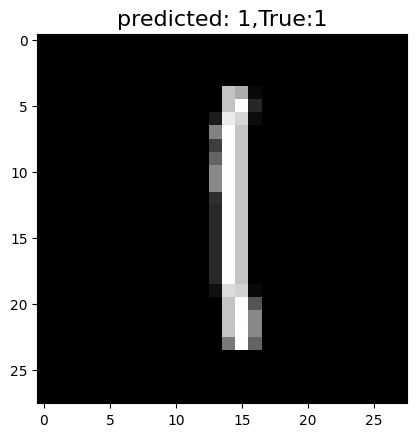

In [12]:
#single example
random_idx = np.random.choice(len(test_images))
x_sample = test_images[random_idx]
y_true = np.argmax(test_labels, axis=1)
y_sample_true = y_true[random_idx]
y_sample_pred_class = y_pred_classes[random_idx]

plt.title("predicted: {},True:{}".format(y_sample_pred_class, y_sample_true),fontsize=16)
plt.imshow(x_sample.reshape(28,28),cmap='gray')

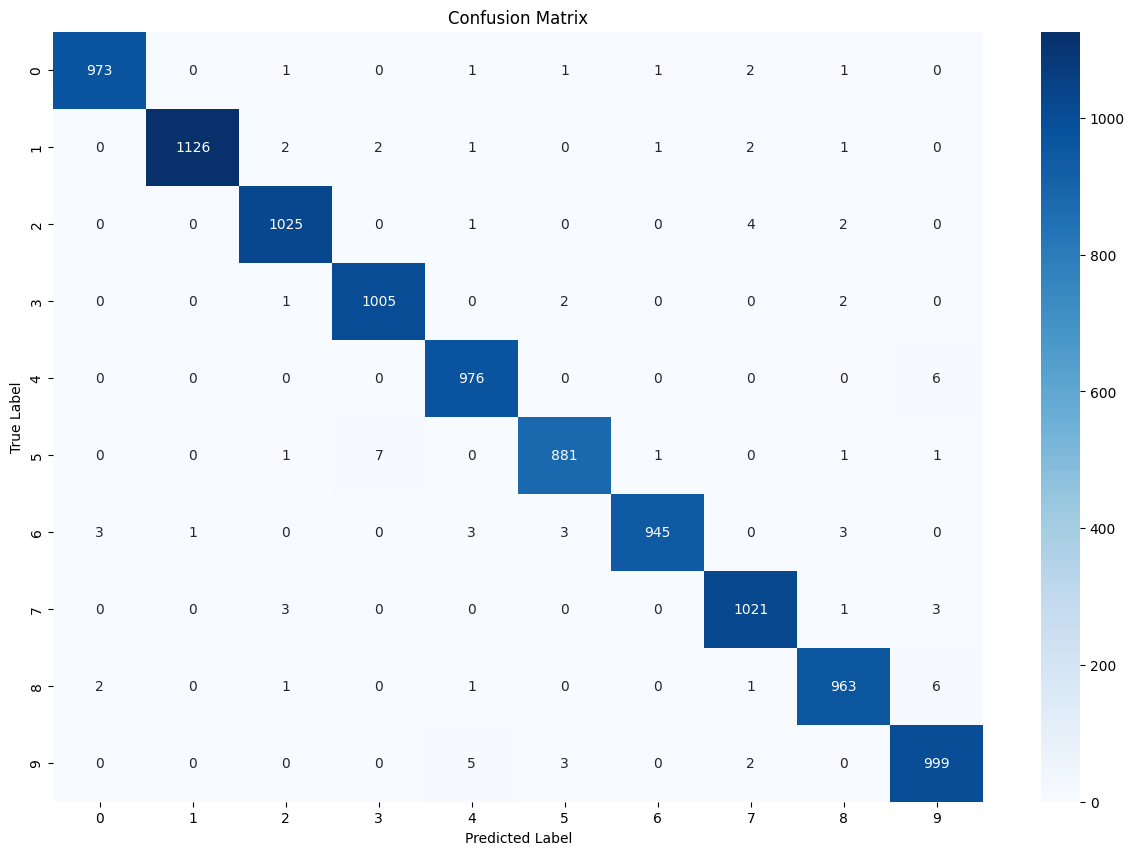

In [23]:
#Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
confusion_mtx = confusion_matrix(y_true, y_pred_classes)

#Plot
fig, ax = plt.subplots(figsize=(15,10))
ax = sns.heatmap(confusion_mtx, annot=True, fmt='d',ax=ax, cmap="Blues")
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix');